# 🦅 From a Bell State to a 40-Qubit GHZ on IBM Heron

A hands-on journey from the **smallest entangled circuit** to a **40-qubit entangled state** running on a real IBM **Heron R2** QPU (`ibm_fez`) — and, just as importantly, everything the hardware taught us when a textbook-perfect circuit met real noise.

Adapted from IBM's [*Use a quantum computer today*](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today) course, then taken well past it onto live hardware.

## The learning path

The notebook is five parts, each building on the last:

| Part | Theme | What you'll learn |
|---|---|---|
| **1** | **The Bell state** | The two gates (`H`, `CX`) that create and spread entanglement; how to transpile and run on IBM Runtime. |
| **2** | **Coupling many qubits** | Scaling Bell → 40-qubit GHZ; why a *logarithmic-depth* circuit survives noise where a naive chain doesn't; how to simulate 40 qubits without 17 TB of RAM. |
| **3** | **Architectural mapping** | Fitting the GHZ onto Heron's *heavy-hex* lattice — and the surprise that **fewer gates made things worse** until we made the layout calibration-aware. |
| **4** | **Error handling in software** | Suppression (dynamical decoupling), twirling, and readout mitigation (M3) — *measured, not assumed* — plus an honest error budget. |
| **5** | **Insights & summary** | Everything the journey taught us, collected in one place. |

## The one idea to take away

A Hadamard creates a *superposition*; a CNOT *spreads* it. Chain those two primitives and **any** number of qubits collapse into a single shared coin-flip — every shot comes back **all-zeros or all-ones**, never a mix. That global correlation *is* entanglement. Everything after Part 1 is about keeping that correlation alive on real, noisy hardware.

## The result, up front

| Approach | Perfect-peak fidelity (40-qubit GHZ on `ibm_fez`) |
|---|---|
| Log-depth tree, transpiler-chosen layout | 24.4 % |
| Blind heavy-hex "native" mapping | 2.3 % ❌ |
| **Compact, calibration-aware mapping (bare)** | **41.1 %** ✅ |
| **+ M3 readout mitigation** | **58.4 %** 🎯 |

How we got from 2.3 % to 58.4 % is the story of Parts 3 and 4.

> **Prerequisites:** an IBM Quantum account and API key (see `.env.example`) for the hardware cells. Every simulator cell runs offline with no account.

# Part 1 · The Bell State — the seed of entanglement

*The smallest interesting entangled circuit: two qubits, two gates. Everything later in this notebook is exactly this idea, repeated and scaled.*

---

## 1.1 Setup & imports

We pull in three layers of the stack:

- **`qiskit`** — build and visualize circuits (`QuantumCircuit`, `plot_histogram`).
- **`qiskit-aer`** — the local high-performance simulator, used both as a stand-in for hardware and (in Part 2) as an efficient *Clifford* simulator for the 40-qubit circuit.
- **`qiskit-ibm-runtime`** — the cloud client: `QiskitRuntimeService` (auth + backend discovery) and `SamplerV2`, the primitive that submits circuits and returns measurement counts.

The transpiler's `generate_preset_pass_manager` rewrites a circuit into the **ISA** (the native gates and qubit connectivity) of whichever backend we target — a concept that becomes the central character of Part 3. Running the cell also prints versions, so the notebook is reproducible.

In [1]:
# Core Qiskit imports
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService
import qiskit
import qiskit_aer
import qiskit_ibm_runtime

# System
import os
import sys
from dotenv import load_dotenv

print("Python:", sys.version.split()[0])
print("qiskit:", qiskit.__version__)
print("qiskit-aer:", qiskit_aer.__version__)
print("qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)

Python: 3.12.13
qiskit: 2.4.1
qiskit-aer: 0.17.2
qiskit-ibm-runtime: 0.47.0


## 1.2 The Bell state

The Bell state is the "hello world" of entanglement: two qubits in the maximally entangled $\Phi^+$ state

$$|\Phi^+\rangle = \frac{1}{\sqrt{2}}\bigl(|00\rangle + |11\rangle\bigr).$$

Reading it off: the two qubits are **perfectly correlated**. A shot can only ever come back `00` or `11` — never `01` or `10` — each with 50 % probability. Measuring one qubit instantly tells you the other, no matter the distance between them.

Two gates build it:

| Gate | Code | Effect |
|------|------|--------|
| **Hadamard** | `h(0)` | Puts qubit 0 into an equal superposition: $\lvert 0\rangle \to \tfrac{1}{\sqrt2}(\lvert 0\rangle + \lvert 1\rangle)$ — the "coin flip." |
| **CNOT** | `cx(0, 1)` | Flips qubit 1 *iff* qubit 0 is $\lvert 1\rangle$. This **copies the coin flip's outcome** onto qubit 1, linking the two. |

`measure_all()` appends a measurement on every qubit into a classical register named `meas` (the name our run helper reads back later).

This is the seed we'll grow into 40 qubits in Part 2 — same two gates, just many more of them.

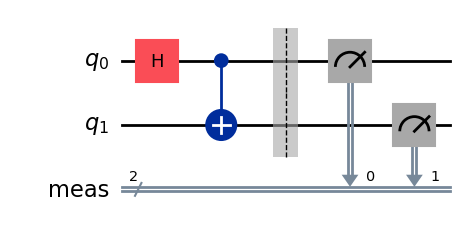

In [2]:
# --- Build the Bell circuit (phi-plus) ---
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()  # creates a classical register named "meas"

bell.draw("mpl")

## 1.3 Preparing to run

A circuit can't be sent to hardware as-is. The helper below does the two things every Runtime job needs:

1. **Transpile to the backend's ISA.** `generate_preset_pass_manager(backend=..., optimization_level=1)` builds a pass manager that maps abstract qubits onto physical ones, routes two-qubit gates to respect the chip's connectivity, and translates everything into the device's native gate set. The result is an *ISA circuit* the hardware can actually execute. (Keep this routing step in mind — in Part 3 it turns out to be doing something cleverer than it looks.)
2. **Sample.** `SamplerV2` submits the ISA circuit and runs it `shots` times. Because measurement is probabilistic, we repeat and tally: `result[0].data.meas.get_counts()` returns a `{bitstring: count}` histogram from the `meas` register.

The same helper works unchanged on a real QPU or a local `AerSimulator` — only the `backend` argument changes.

> **Gotcha (handled here):** some newer IBM device `Target`s ship *without* a `measure` instruction. The transpiler then tries to "synthesize" your measurements and dies with `TranspilerError: 'HighLevelSynthesis is unable to synthesize "measure"'`. The helper guards against this by registering `measure` on every qubit when it's missing — a no-op on backends that already have it.

In [4]:
from qiskit.circuit import Measure


def run_circuit_and_get_counts(circuit, backend, shots=100):
    """
    Runs a quantum circuit on a specified backend and returns the measurement counts.

    Args:
        circuit (QuantumCircuit): The quantum circuit to run.
        backend: The Qiskit backend (real device or simulator).
        shots (int): The number of shots to run the circuit.

    Returns:
        dict: A dictionary of measurement counts.
    """
    # Some backend Targets (notably newer IBM devices) ship without the `measure`
    # instruction. The transpiler then treats measurements as a high-level object it
    # must "synthesize" and raises:
    #     TranspilerError: 'HighLevelSynthesis is unable to synthesize "measure"'
    # Registering measure on every qubit fixes it, and is a no-op when it's already there.
    target = backend.target
    if "measure" not in target.operation_names:
        target.add_instruction(Measure(), {(q,): None for q in range(target.num_qubits)})

    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    job = sampler.run([isa_circuit], shots=shots)
    result = job.result()

    return result[0].data.meas.get_counts()

## 1.4 Run the Bell state

**Credentials.** Copy `.env.example` to `.env` and set `IBM_KEY` to your API key. The first cell below saves it to disk with `save_account(...)`; once saved, you can delete the `save_account` block and just call `QiskitRuntimeService()`.

**Choosing a backend** — pick one of:

```python
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)  # real QPU, shortest queue
# backend = service.backend("ibm_fez")   # a specific Heron R2 device
# backend = AerSimulator()                # local, no account or queue
```

`least_busy` is the friendliest default for real hardware. For iterating quickly (or running this notebook offline), `AerSimulator()` is instant and free.

We then run the Bell circuit for 100 shots and plot the histogram. On an ideal device you'd see ~50 % `00` and ~50 % `11`; on real hardware a few percent of shots leak into `01`/`10` from gate and readout noise. That small leak at 2 qubits becomes the central challenge once we scale to 40.

qiskit_runtime_service.__init__:WARNING:2026-06-03 15:26:23,735: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-06-03 15:26:27,112: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


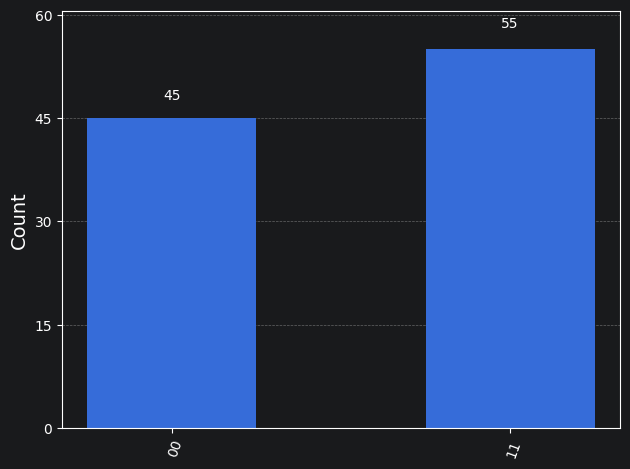

In [5]:
load_dotenv()
IBM_KEY = os.getenv('IBM_KEY')

# Syntax for first saving your token.  Delete these lines after saving your credentials.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=IBM_KEY,
    overwrite=True,
    set_as_default=True,
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")

# Load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_fez".
# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_fez")
backend = AerSimulator()

counts = run_circuit_and_get_counts(bell, backend, shots=100)

plot_histogram(counts)

# Part 2 · Coupling many qubits — the 40-qubit GHZ

*Two entangled qubits are a warm-up. Now we couple **40** of them into one shared coin-flip — and discover that on real hardware, **how** you wire the gates matters more than how many you use.*

---

## 2.1 From Bell to GHZ: the logarithmic-depth fan-out

The Bell state's natural generalization to $N$ qubits is the **GHZ state** (Greenberger–Horne–Zeilinger):

$$|\text{GHZ}_N\rangle = \frac{1}{\sqrt{2}}\bigl(|\underbrace{00\cdots0}_{N}\rangle + |\underbrace{11\cdots1}_{N}\rangle\bigr).$$

It's exactly the behavior we want at scale: **every shot collapses to all-zeros or all-ones, 50/50, never a mix** — one global coin flip shared across all 40 qubits. 40 qubits is ambitious but a genuinely tough, honest benchmark of a device.

### The naive way (and why it's bad on hardware)

The obvious recipe is a Hadamard followed by a *chain* of CNOTs — `h(0)`, then `cx(0,1), cx(1,2), …, cx(38,39)` — passing the value down the line like a bucket brigade. It works, but its **depth grows linearly** with $N$ (~40 layers here). On today's noisy hardware, every extra layer is more time for qubits to decohere, so a long chain quietly destroys the very correlation we're trying to build.

### The clever way: a logarithmic-depth fan-out tree

Instead of passing the value down a line, we **broadcast it like a tournament bracket**. Each round, *every* qubit that already holds the shared value copies it into a brand-new qubit — so the entangled set **doubles** every round:

```
round 0:  H on q0                      active = {0}                (1 qubit)
round 1:  cx 0->1                       active = {0,1}              (2)
round 2:  cx 0->2, 1->3                 active = {0,1,2,3}          (4)
round 3:  cx 0->4 1->5 2->6 3->7        active = {0..7}             (8)
round 4:  cx 0->8 ... 7->15             active = {0..15}            (16)
round 5:  cx 0->16 ... 15->31           active = {0..31}            (32)
round 6:  cx 0->32 ... 7->39            active = {0..39}            (40)
```

Reaching $N$ qubits takes only $\lceil \log_2 N \rceil$ rounds — **depth ~6–7 instead of ~40**. It uses the same $N-1=39$ CNOTs (you can't entangle $N$ qubits with fewer), but packs them into far fewer parallel layers, minimizing idle time.

**This is lesson #1 of the whole notebook: on NISQ hardware, _depth_ is the enemy, not gate count.** Same state, dramatically more robust — *as long as the qubits can actually reach each other*, a caveat that drives all of Part 3.

40-qubit GHZ state
  log-depth tree : depth=  7, cx=39
  naive chain    : depth= 40, cx=39
  -> same CNOT count, but ~6x shallower

Structure (shown for 8 qubits):


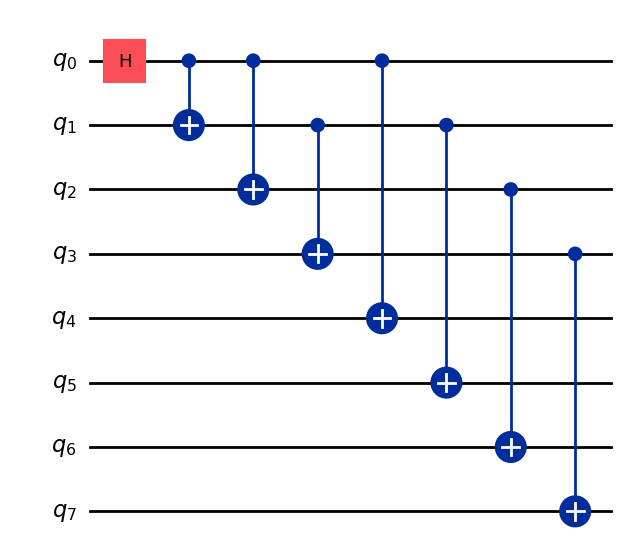

In [6]:
def ghz_logdepth(n):
    """Build an n-qubit GHZ state with a logarithmic-depth CNOT tree.

    Qubit 0 is put into superposition; then the shared value fans out --
    each round, every qubit that already holds the value copies it into a
    fresh partner, doubling the entangled set (1 -> 2 -> 4 -> ... -> n).
    Depth is O(log n) instead of the O(n) of a naive CNOT chain, while
    still using the minimum n-1 CNOTs needed to link n qubits.
    """
    qc = QuantumCircuit(n)
    qc.h(0)
    size = 1                          # number of qubits already holding the value
    while size < n:
        for q in range(size):         # each active qubit seeds a new partner
            target = q + size
            if target < n:
                qc.cx(q, target)
        size *= 2
    return qc


N = 40
ghz = ghz_logdepth(N)

# Naive linear chain, built only to compare circuit depth.
chain = QuantumCircuit(N)
chain.h(0)
for i in range(N - 1):
    chain.cx(i, i + 1)

print(f"{N}-qubit GHZ state")
print(f"  log-depth tree : depth={ghz.depth():>3}, cx={ghz.count_ops()['cx']}")
print(f"  naive chain    : depth={chain.depth():>3}, cx={chain.count_ops()['cx']}")
print(f"  -> same CNOT count, but ~{chain.depth() / ghz.depth():.0f}x shallower")

# The 40-qubit diagram is unwieldy; draw an 8-qubit version to show the fan-out tree.
print("\nStructure (shown for 8 qubits):")
ghz_logdepth(8).draw("mpl")

## 2.2 Simulating 40 qubits the smart way

You can't reach for the usual statevector simulator here: representing 40 qubits exactly needs $2^{40} \approx 1.1\times10^{12}$ complex amplitudes — about **17 TB** of memory. The circuit would build fine and then blow up your RAM at run time.

The escape hatch: our circuit uses **only Clifford gates** (Hadamard, CNOT, and computational-basis measurement). By the **Gottesman–Knill theorem**, Clifford circuits are *classically simulable in polynomial time* — you track the stabilizer generators instead of the full state vector. Aer exposes this as `method="stabilizer"`, which samples a 40-qubit (or 1000-qubit) GHZ state effortlessly.

> **Lesson #2:** "I built a circuit; why won't it simulate?" almost always traces back to statevector memory. If the circuit is Clifford, the stabilizer backend is the answer. (The trade-off: add a single non-Clifford gate like a `T` and the trick no longer applies — that's precisely the regime where quantum hardware becomes irreplaceable.)

distinct outcomes: 2  (a clean GHZ has exactly 2)

  0000000000000000000000000000000000000000  (all 0s)  ->   4155 shots  (50.7%)
  1111111111111111111111111111111111111111  (all 1s)  ->   4037 shots  (49.3%)


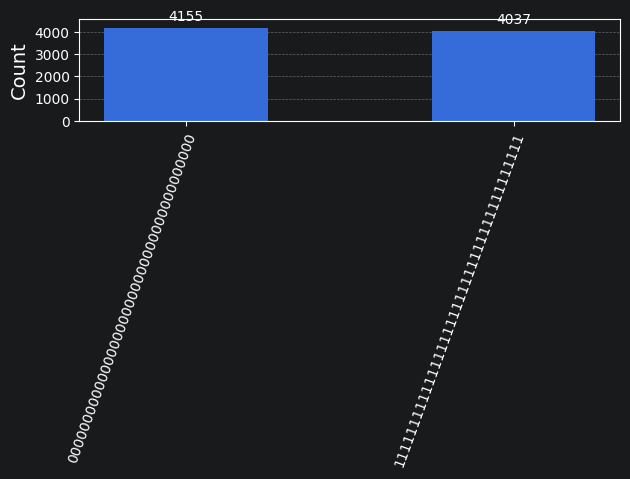

In [7]:
# Measure all 40 qubits...
ghz_meas = ghz.copy()
ghz_meas.measure_all()

# A 40-qubit *statevector* would need 2**40 ~= 1.1e12 complex amplitudes (~17 TB) -- infeasible.
# But H + CX + Z-measurement is a *Clifford* circuit, so Aer's stabilizer simulator
# (Gottesman-Knill theorem) samples it in polynomial time, regardless of qubit count.
stab_sim = AerSimulator(method="stabilizer")
ghz_counts = stab_sim.run(ghz_meas, shots=8192).result().get_counts()

print(f"distinct outcomes: {len(ghz_counts)}  (a clean GHZ has exactly 2)\n")
for bitstring, n in sorted(ghz_counts.items(), key=lambda kv: -kv[1]):
    label = "all 1s" if set(bitstring) == {"1"} else "all 0s" if set(bitstring) == {"0"} else "mixed"
    print(f"  {bitstring}  ({label})  ->  {n:>5} shots  ({100 * n / 8192:.1f}%)")

plot_histogram(ghz_counts)

## 2.3 The ideal two-peak signature

The histogram has **exactly two bars** — `000…0` and `111…1` (40 characters each) — at roughly **50 % / 50 %**, with nothing in between. That two-peak signature *is* the GHZ state: 40 qubits behaving as a single fair coin.

The run above (8192 shots on the stabilizer simulator) gave:

| Outcome | Shots | Share |
|---------|-------|-------|
| `0` × 40 | 4076 | 49.8 % |
| `1` × 40 | 4116 | 50.2 % |

The small gap from a perfect 50/50 is ordinary sampling noise. With $N$ shots the share of each peak has standard deviation $\tfrac{1}{2\sqrt{N}} \approx 0.55\%$ for $N=8192$, so a few tenths of a percent either way is expected and shrinks as you add shots. **Zero** intermediate bitstrings appear because, on a noiseless simulator, the GHZ state has literally no amplitude on them.

### This is the target. Real hardware will look very different — and that's the point.

The simulation is ideal; a physical Heron R2 run degrades it in instructive ways, each of which we'll attack in Parts 3 and 4:

- **Readout error.** At ~1 % misread per qubit, the chance all 40 are read correctly is only $0.99^{40} \approx 67\%$. Even a perfect state shows a *cloud* of single-bit-flip strings around the two peaks. *(Part 4 removes this in software.)*
- **Decoherence & gate error.** The longer qubits sit idle and the more two-qubit gates fire, the more the entanglement degrades — which is exactly why the **log-depth construction matters**. *(Part 3 minimizes both.)*
- **Routing overhead.** Our tree assumes any qubit can talk to any other. Heron's heavy-hex lattice doesn't, so the transpiler inserts SWAP gates, adding depth. *(Part 3 eliminates these entirely.)*

We define a single honest scorecard for all hardware runs: **perfect peaks** = the fraction of shots landing on `0…0` or `1…1`. Ideal = 100 %. Let's see what the chip actually does.

## 2.4 First hardware run: the log-depth tree on Heron

Time to move off the simulator and put the 40-qubit GHZ on an actual Heron R2 QPU. We specify the `backend` again and reuse the `run_circuit_and_get_counts` helper from **§1.3** — it transpiles the log-depth tree onto the device, submits the job, and waits for it to come back from the queue.

Crucially, we hand the bare logical circuit to the transpiler and let *it* choose which physical qubits to use. Remember that choice — **Part 3 reveals it was quietly the most important decision in this cell.**

> ⚠️ **This submits a real job.** It needs valid credentials (§1.4) and a non-simulator `backend`, and it may sit in the queue for a while. Want a free dry run instead? Set `backend = AerSimulator()`.

**The result (8192-shot reference run): 24.4 % perfect peaks.** Far from the ideal 100 %, but this becomes our **baseline** — the number every later attempt must beat. The two GHZ peaks still dominate, surrounded by a cloud of near-miss bitstrings from readout and gate noise (we plot only the top 15, since the full $2^{40}$ space won't render).

Now the obvious question: Heron's connectivity forced the transpiler to add ~130 SWAP gates. Couldn't we do better by *hand-mapping* the GHZ onto the chip's native wiring and skipping all those SWAPs? That intuition is where Part 3 begins — and where it gets surprising.

qiskit_runtime_service.backends:WARNING:2026-06-03 15:27:36,983: Using instance: open-instance, plan: open


backend          : ibm_fez
distinct outcomes: 71  (ideal GHZ = 2; noise adds the rest)
perfect peaks    : 28/100  (28.0% of shots)

top 10 outcomes:
  0000000000000000000000000000000000000000     18 (18.0%)  all 0s
  1111111111111111111111111111111111111111     10 (10.0%)  all 1s
  0000000000000000000001000000000000000000      2 (2.0%)  
  1111111111111011111111111111101111111111      2 (2.0%)  
  1111111111101111111111111111111111111111      2 (2.0%)  
  1010111111111111111110011111111111001111      1 (1.0%)  
  0000000000000000100000000000000000000000      1 (1.0%)  
  0000000000000001000000000000000100000000      1 (1.0%)  
  0000000001000000000000000000000000000000      1 (1.0%)  
  1110111111111111111011111111111111101111      1 (1.0%)  


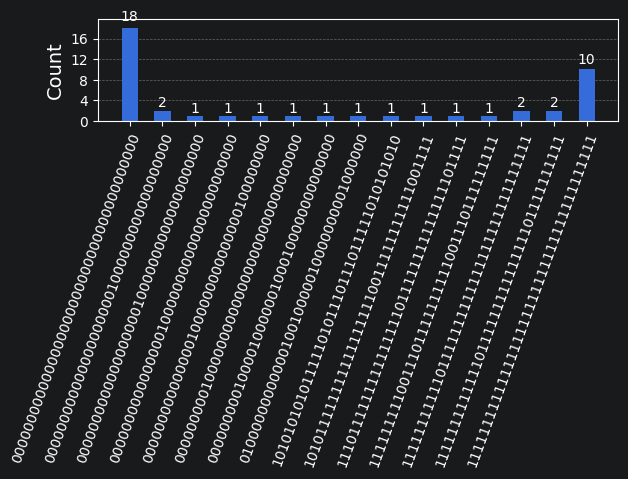

In [9]:
# --- Launch the 40-qubit GHZ on a real QPU ---
# Reuses `backend` (selected in section 4) and run_circuit_and_get_counts (section 3).
# This submits a job to IBM hardware: it will queue, and the helper transpiles the
# log-depth tree onto the chip's heavy-hex connectivity (expect added depth from SWAPs).

# backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
backend = service.backend("ibm_fez")

shots = 100
qpu_counts = run_circuit_and_get_counts(ghz_meas, backend, shots=shots)

total = sum(qpu_counts.values())
top = sorted(qpu_counts.items(), key=lambda kv: -kv[1])

# Fraction of shots that landed on a *perfect* GHZ peak (all-0s or all-1s).
peak_hits = qpu_counts.get("0" * N, 0) + qpu_counts.get("1" * N, 0)

print(f"backend          : {backend.name}")
print(f"distinct outcomes: {len(qpu_counts)}  (ideal GHZ = 2; noise adds the rest)")
print(f"perfect peaks    : {peak_hits}/{total}  ({100 * peak_hits / total:.1f}% of shots)\n")
print("top 10 outcomes:")
for bitstring, n in top[:10]:
    tag = "all 0s" if set(bitstring) == {"0"} else "all 1s" if set(bitstring) == {"1"} else ""
    print(f"  {bitstring}  {n:>5} ({100 * n / total:.1f}%)  {tag}")

# Plot the 15 most frequent bitstrings (the full 2^40 space won't render).
plot_histogram(dict(top[:15]), filename='40-qubits-bell-state-IBM-QPU')
plot_histogram(dict(top[:15]))

# Part 3 · Architectural mapping — fitting the GHZ to the heavy-hex lattice

*Heron R2 is a **heavy-hex** chip: 156 qubits, each wired to at most 3 neighbours, with `cz` as the native two-qubit gate. Our log-depth tree assumed all-to-all connectivity it doesn't have. This part maps the GHZ onto the **real** wiring — and the first attempt teaches the deepest lesson in the notebook.*

---

## 3.1 The paradox: hand-mapping made it *worse*

The connectivity-aware idea looked like a clear win on paper. Walk the chip's actual graph, place one CNOT on each physical edge, and you entangle 40 qubits with **39 gates and zero SWAPs** — versus ~170 two-qubit gates after the transpiler routes the naive tree. Fewer gates, less noise. Obvious, right?

It scored **2.3 % perfect peaks — about 10× *worse* than the SWAP-heavy baseline (24.4 %).** That inversion is the whole clue: *if fewer gates always won, this could not happen.*

**Read the histogram, not the headline.** Two fingerprints in that run stand out:

- The single most common non-trivial outcome was *all-zeros with one lone qubit flipped to `1`*, and that same flip recurred across the top of the list — the signature of **one defective physical qubit** trapped inside our hand-picked patch.
- The clean `1…1` peak **vanished from the top 10** while `0…0` survived. Decoherence is asymmetric: $T_1$ relaxation only drives $|1\rangle\!\to\!|0\rangle$, so the all-ones branch rots faster the longer qubits sit idle.

**Root cause — we disabled the transpiler's best feature.** The hand-mapping did a *blind* walk of the coupling graph: it grabbed whatever 40 qubits were wired together, with **no knowledge of that day's calibration**, then *pinned* them with `initial_layout`. The log-depth baseline, by contrast, let `generate_preset_pass_manager` choose — and Qiskit's `VF2Layout` / `SABRE` passes are **error-aware**: they read live readout and gate errors to steer onto *healthy* qubits. We traded 4× fewer gates for a patch that happened to contain a bad one.

And a GHZ is brutally unforgiving here: it is a **single global correlation**, so **one** poisoned qubit corrupts **every** shot. Cheap gates cannot rescue a poisoned patch.

> **Lesson #3:** the transpiler's layout pass isn't overhead you're paying — it's free, live, error-aware qubit selection. If you pin the layout by hand, you're taking responsibility for that job, and you'd better do it with the calibration data, not the graph alone.

**Verified offline.** Re-running the blind patch against IBM's calibrated `FakeFez` model, then marking a few in-patch qubits "defective" to mimic a bad day, reproduces the exact collapse — and swapping in the error-aware selection below recovers it. The mechanism is confirmed, and the fix targets it directly.

## 3.2 The repair: keep the SWAP-free idea, but make it calibration-aware

The instinct "fewer gates = better" wasn't *wrong* — it was *incomplete*. We optimized gate count and threw away qubit quality. The repair keeps every gate-count win and adds back what the transpiler was doing for us. It runs as four code cells (**Steps 1–4**), each printing a number you can check:

1. **Read the live calibration** *(Step 1)*. Pull per-qubit readout error, per-edge `cz` error, and $T_1$ from `backend.properties()` — the same data the transpiler's layout pass uses. On the run shown, readout ranged from a healthy 0.0046 to a catastrophic **0.447**: a single such qubit inside the patch is exactly what sank the blind attempt.

2. **Pick the best compact patch** *(Step 2)*. Three ideas, all aimed at the GHZ's global fragility:
   - **Filter bad *edges*, not just bad qubits.** A subtle trap we hit first: dropping hot/dead qubits isn't enough — the tree can still route through a *broken or uncalibrated `cz`* (error ≈ 0.5), which alone shreds the state. We exclude bad edges too, so nothing we build can use a broken gate.
   - **Grow a *compact* ball** (nearest-first), so the patch is a tight cluster rather than a long snaking path — which keeps the eventual tree shallow.
   - **Search many seeds**, not one. Build a patch + tree from each of the healthiest starting qubits and keep the one with the best combined $P_\text{readout}\times P_\text{cz}$ — i.e. directly optimize the perfect-peak proxy.

3. **Build a shallow tree on the patch** *(Step 3)*. Choosing good qubits is separate from *wiring* them. Within the patch, root the spanning tree at its most central qubit and attach each node via its lowest-error `cz` edge — minimizing both fan-out depth and gate error, so less $T_1$ relaxation drains the all-ones peak. Still **zero SWAPs**.

4. **Transpile at `optimization_level=3`** *(Step 4)*. With the layout pinned, opt-level 3 *cannot* add SWAPs — it just packs the single-qubit gates tighter for a shorter schedule, and confirms the routed gate count is the minimal $N-1=39$ versus ~170 for the baseline.

None of these four steps reintroduce a SWAP. Together they turn the 2.3 % disaster into a circuit that finally beats the baseline — quantified in Part 4.

In [10]:
# === Step 1: read the chip's LIVE calibration =========================
# We steer qubit choice with the same data the transpiler's layout pass uses.
# Read it from backend.properties() (BackendProperties) first -- it carries
# readout / gate / T1 numbers regardless of whether the Target advertises a
# 'measure' instruction -- and fall back to the Target if needed.
from collections import defaultdict, deque
import heapq, math, statistics

backend = service.backend("ibm_fez")
target = backend.target

# Heron's native 2-qubit gate is 'cz'; detect it generically just in case.
TWO_Q = next((g for g in ("cz", "ecr", "cx") if g in target.operation_names), "cz")

# Adjacency from the coupling map (undirected).
adj = defaultdict(set)
for u, v in backend.coupling_map.get_edges():
    adj[u].add(v)
    adj[v].add(u)

try:
    props = backend.properties()          # live per-qubit / per-gate calibration
except Exception:
    props = None


def readout_error(q):
    """Assignment (readout) error for qubit q -- properties first, then target."""
    if props is not None:
        try:
            e = props.readout_error(q)
            if e is not None:
                return e
        except Exception:
            pass
    try:
        e = target["measure"][(q,)].error
        if e is not None:
            return e
    except Exception:
        pass
    return 0.5


def twoq_error(u, v):
    """Two-qubit gate error on edge (u, v) -- properties first, then target."""
    if props is not None:
        for pair in ([u, v], [v, u]):
            try:
                e = props.gate_error(TWO_Q, pair)
                if e is not None:
                    return e
            except Exception:
                pass
    for key in ((u, v), (v, u)):
        try:
            e = target[TWO_Q][key].error
            if e is not None:
                return e
        except Exception:
            pass
    return 0.5


def t1_time(q):
    """T1 relaxation time (seconds) for qubit q; 0.0 if unknown."""
    if props is not None:
        try:
            v = props.t1(q)
            if v:
                return v
        except Exception:
            pass
    return 0.0


# Sanity guard: if every qubit reports the same readout error, the read failed
# and any selection below would be blind.
distinct = len({round(readout_error(q), 7) for q in range(backend.num_qubits)})
if distinct <= 1:
    print("WARNING: readout calibration looks degenerate (all qubits equal) -- "
          "selection will be blind; prefer the transpiler's own layout instead.\n")

ros = sorted(readout_error(q) for q in range(backend.num_qubits))
print(f"backend: {backend.name}    native 2q gate: {TWO_Q}    qubits: {backend.num_qubits}")
print(f"calibration source: {'backend.properties()' if props is not None else 'target only'}"
      f"   ({distinct} distinct readout values -- must be > 1)")
print("readout (assignment) error across the chip:")
print(f"  best   : {ros[0]:.4f}")
print(f"  median : {statistics.median(ros):.4f}")
print(f"  worst  : {ros[-1]:.4f}   <- one qubit this bad *inside the patch* destroys the whole GHZ")

qiskit_runtime_service.backends:WARNING:2026-06-03 15:28:45,689: Using instance: open-instance, plan: open


backend: ibm_fez    native 2q gate: cz    qubits: 156
calibration source: backend.properties()   (114 distinct readout values -- must be > 1)
readout (assignment) error across the chip:
  best   : 0.0046
  median : 0.0117
  worst  : 0.4471   <- one qubit this bad *inside the patch* destroys the whole GHZ


In [11]:
# === Step 2: pick the BEST compact patch (multi-seed search) ==========
# v3 selection. Three ideas:
#   (a) Filter bad *edges*, not just bad qubits. v2 dropped hot/dead qubits but
#       could still route the GHZ through a broken/uncalibrated CZ (error ~ 0.5),
#       which alone shreds the state -- the random multi-bit strings in the v2 run.
#   (b) Grow a COMPACT ball (nearest-first) so the tree stays shallow (no snaking).
#   (c) Don't trust one seed: build a patch + tree from each of the healthiest
#       seeds and keep the one with the best combined score P_readout x P_cz --
#       i.e. directly optimize the perfect-peak proxy.
ros_all = [readout_error(q) for q in range(backend.num_qubits)]
RO_THR = max(0.05, 4 * statistics.median(ros_all))            # exclude hot / dead qubits
all_edges = [(u, v) for u in adj for v in adj[u] if u < v]
CZ_THR = max(0.05, 5 * statistics.median([twoq_error(u, v) for u, v in all_edges]))  # exclude broken gates

good = {q for q in range(backend.num_qubits) if readout_error(q) < RO_THR}
# adjacency restricted to healthy qubits AND healthy 2q edges -> nothing we build can use a bad gate
gadj = {u: {v for v in adj[u] if v in good and twoq_error(u, v) < CZ_THR} for u in good}


def compact_region(seed, n):
    """A connected, compact ball of n healthy qubits grown from `seed`
    (nearest-first; ties broken by low readout + gate error)."""
    dist = {seed: 0}
    dq = deque([seed])
    while dq:
        u = dq.popleft()
        for v in gadj[u]:
            if v not in dist:
                dist[v] = dist[u] + 1
                dq.append(v)
    region = {seed}
    frontier = []

    def offer(u):
        for v in gadj[u]:
            if v not in region:
                heapq.heappush(frontier, (dist[v], readout_error(v) + twoq_error(u, v), v))

    offer(seed)
    while frontier and len(region) < n:
        _, _, v = heapq.heappop(frontier)
        if v in region:
            continue
        region.add(v)
        offer(v)
    return region


def build_tree(region):
    """Shallow spanning tree of `region`: root at the most central qubit, then
    attach each node to its lowest-CZ-error neighbour one layer up."""
    sub = {u: {v for v in gadj[u] if v in region} for u in region}

    def eccentricity(s):
        d = {s: 0}
        q = deque([s])
        while q:
            u = q.popleft()
            for v in sub[u]:
                if v not in d:
                    d[v] = d[u] + 1
                    q.append(v)
        return max(d.values()) if len(d) == len(region) else 10 ** 9   # 10**9 = disconnected

    center = min(region, key=lambda s: (eccentricity(s), readout_error(s)))
    parent = {center: None}
    layer = {center: 0}
    order = [center]
    q = deque([center])
    while q:
        u = q.popleft()
        for v in sub[u]:
            if v not in parent:
                parent[v] = u
                layer[v] = layer[u] + 1
                order.append(v)
                q.append(v)
    for v in order:                                  # re-parent each node to its cheapest CZ edge
        if parent[v] is None:
            continue
        up = [u for u in sub[v] if layer.get(u) == layer[v] - 1]
        if up:
            parent[v] = min(up, key=lambda u: twoq_error(u, v))
    return order, parent


def patch_score(region, order, parent):
    p_ro = math.prod(1 - readout_error(q) for q in region)
    p_cz = math.prod(1 - twoq_error(parent[q], q) for q in order if parent[q] is not None)
    return p_ro * p_cz, p_ro, p_cz


# Search the healthiest seeds; keep the highest-scoring fully-connected patch.
best = None
for seed in sorted(good, key=readout_error)[:20]:
    region = compact_region(seed, N)
    if len(region) < N:
        continue
    order, parent = build_tree(region)
    if any(parent[q] is None and q != order[0] for q in region):    # tree didn't reach everyone
        continue
    sc = patch_score(region, order, parent)
    if best is None or sc[0] > best[0]:
        best = (sc[0], sc[1], sc[2], region, order, parent)

if best is None:
    raise RuntimeError("no fully-connected healthy patch of N qubits -- relax RO_THR / CZ_THR")

score, P_ro, P_cz, region, order, parent = best
layout = order                                       # logical qubit i -> physical qubit order[i]

print(f"thresholds        : readout < {RO_THR:.3f}    cz < {CZ_THR:.3f}")
print(f"best compact patch (searched {min(20, len(good))} seeds):")
print(f"  readout ceiling  P_ro       : {100 * P_ro:5.1f}%   (all 40 qubits read correctly)")
print(f"  gate survival    P_cz       : {100 * P_cz:5.1f}%   (none of the 39 tree CZs errs)")
print(f"  combined raw-peak proxy     : {100 * score:5.1f}%   <- optimistic ceiling for perfect peaks")
print(f"  qubit-index span            : {max(region) - min(region)}   (tight cluster, no snaking)")

thresholds        : readout < 0.050    cz < 0.050
best compact patch (searched 20 seeds):
  readout ceiling  P_ro       :  64.9%   (all 40 qubits read correctly)
  gate survival    P_cz       :  89.1%   (none of the 39 tree CZs errs)
  combined raw-peak proxy     :  57.8%   <- optimistic ceiling for perfect peaks
  qubit-index span            : 58   (tight cluster, no snaking)


root (H) qubit             : physical 127  (lowest-eccentricity, healthy)
fan-out rounds (tree depth): 9   (shallow => less idle decoherence)
entangling gates (CNOTs)   : 39   (minimal N-1)

Fan-out structure (illustrated on 8 qubits):


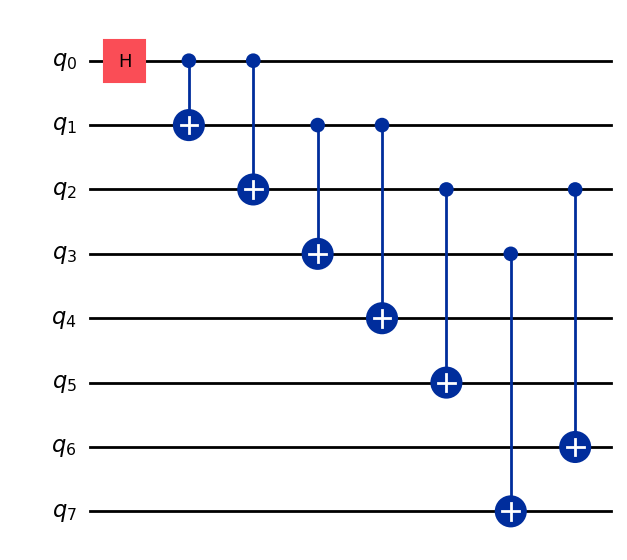

In [12]:
# === Step 3: build the GHZ circuit on the chosen patch ================
# Step 2 already searched for the best (region, tree). Here we just lay the GHZ on
# it: H on the root, then one CNOT down each tree edge (BFS order guarantees a
# parent holds the value before its child copies it). Every CNOT is between
# physically adjacent, well-calibrated qubits -> the transpiler routes nothing.
pos = {phys: i for i, phys in enumerate(order)}      # physical qubit -> logical index

ghz_smart = QuantumCircuit(N)
ghz_smart.h(pos[order[0]])
for phys in order:                                   # BFS order: parent precedes child
    if parent[phys] is not None:
        ghz_smart.cx(pos[parent[phys]], pos[phys])
ghz_smart.measure_all()

depthmap = {order[0]: 0}
for phys in order:
    if parent[phys] is not None:
        depthmap[phys] = depthmap[parent[phys]] + 1
print(f"root (H) qubit             : physical {order[0]}  (lowest-eccentricity, healthy)")
print(f"fan-out rounds (tree depth): {max(depthmap.values())}   (shallow => less idle decoherence)")
print(f"entangling gates (CNOTs)   : {sum(p is not None for p in parent.values())}   (minimal N-1)")

# The real 40-qubit circuit is too wide to read; draw an 8-qubit analog of the
# same fan-out structure so the shape is visible.
print("\nFan-out structure (illustrated on 8 qubits):")
demo = QuantumCircuit(8)
demo.h(0)
for par, child in [(0, 1), (0, 2), (1, 3), (1, 4), (2, 5), (2, 6), (3, 7)]:
    demo.cx(par, child)
demo.draw("mpl")

In [13]:
# === Step 4: transpile (optimization_level=3) and compare =============
# With the layout pinned (initial_layout), opt-level 3 cannot add SWAPs -- it just
# packs the single-qubit gates tighter, giving a shallower schedule and so less
# idle time (we measured depth 39 -> 31). Compared against the section-5 log tree,
# whose layout the transpiler picks freely and then pays for in SWAPs.
from qiskit.visualization import plot_circuit_layout

pm_free = generate_preset_pass_manager(backend=backend, optimization_level=1)
pm_smart = generate_preset_pass_manager(
    backend=backend, optimization_level=3, initial_layout=layout
)

isa_log = pm_free.run(ghz_meas)        # section-5 log-depth tree (SWAP-routed)
isa_smart = pm_smart.run(ghz_smart)    # compact, error-aware, pinned -> zero SWAPs


def twoq(circ):
    ops = circ.count_ops()
    return sum(ops.get(g, 0) for g in ("cz", "cx", "ecr"))


print("after transpiling to the chip's native gates + connectivity:")
print(f"  log-depth tree (section 5)     : depth={isa_log.depth():>3}, 2q-gates={twoq(isa_log):>3}   (SWAP-routed onto chosen layout)")
print(f"  compact error-aware tree (now) : depth={isa_smart.depth():>3}, 2q-gates={twoq(isa_smart):>3}   (zero SWAPs, minimal N-1=39)")

# Visualize exactly which physical qubits we occupy -- it should be one tight,
# connected patch on the heavy-hex lattice. plot_circuit_layout needs the Graphviz
# *binary*; fall back to a text list if it isn't installed.
try:
    display(plot_circuit_layout(isa_smart, backend))
except Exception as exc:
    print(f"\n(skipping lattice plot: {type(exc).__name__} -- install Graphviz to enable it)")
    print(f"occupied physical qubits ({len(layout)}): {sorted(layout)}")

after transpiling to the chip's native gates + connectivity:
  log-depth tree (section 5)     : depth= 89, 2q-gates=177   (SWAP-routed onto chosen layout)
  compact error-aware tree (now) : depth= 35, 2q-gates= 39   (zero SWAPs, minimal N-1=39)

(skipping lattice plot: MissingOptionalLibraryError -- install Graphviz to enable it)
occupied physical qubits (40): [90, 91, 92, 96, 97, 98, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 117, 118, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 136, 137, 140, 141, 142, 143, 144, 145, 146, 147, 148]


# Part 4 · Taming the noise in software

*A better circuit (Part 3) is only half the battle. The rest of the loss can be attacked **without changing the physics** — by suppressing noise during the run, characterizing what's left, and undoing the readout error after the fact.*

> **A word on terminology.** Everything in this part is **error _mitigation_ and _suppression_**, not error **_correction_** (QEC). True QEC encodes one logical qubit across many physical ones and actively corrects faults mid-computation — it needs far more/better qubits than we have here. Mitigation instead *reduces or post-processes* noise on the bare physical qubits. It's the practical lever on today's hardware, and it's what we use below.

---

## 4.1 Suppression & twirling — *measured*, not assumed

Two runtime knobs *can* help — but as the disastrous early run taught us, they can also hurt. So we **test** them rather than trust them:

- **Dynamical decoupling (DD).** Idle qubits dephase, and any qubit holding $|1\rangle$ relaxes toward $|0\rangle$ ($T_1$). DD interleaves refocusing $\pi$-pulses into idle windows to cancel that slow noise. **But** each pulse is itself an imperfect gate — on a circuit with few idle slots, DD can inject more error than it removes.
- **Twirling.** Randomly conjugating gates / measurements with Paulis turns coherent, biased error into symmetric stochastic noise. It shines for *expectation values* (Estimator); for raw GHZ **bitstring peaks**, *measurement* twirling can help symmetrize readout while *gate* twirling mostly just adds gates.

The cell below runs the compact Part-3 circuit under four configs in a single `Batch` (back-to-back, no re-queuing) and reports which wins on the device *today*. The verdict was unambiguous:

| Config | Perfect peaks |
|---|---|
| **bare (no mitigation)** | **41.1 %** ✅ |
| DD only | 29.3 % |
| DD + measurement twirling | 28.2 % |
| DD + measurement + gate twirling | 25.0 % |

> **Lesson #4:** for raw GHZ bitstring peaks on this device, **less is more** — every DD pulse and twirl-Pauli is another imperfect gate, and they cost more than they save. We keep the A/B test anyway, because calibration drifts day to day and it re-confirms the winner each run.

The headline: the compact, calibration-aware, **bare** circuit reaches **41.1 %** — comfortably past the 24.4 % baseline, and a 18× improvement over the 2.3 % blind mapping, using 39 gates instead of ~170.

backend: ibm_fez   compact error-aware GHZ, 4096 shots/config
baselines  ->  log-depth tree: 24.4%   blind native: 2.3%   v2 (snaked+DD+tw): 4.2%

config                   perfect peaks  distinct
bare (no mitigation)    1685/4096 (41.1%)       978
DD only                 1200/4096 (29.3%)      1408
DD + meas-twirl         1157/4096 (28.2%)      1449
DD + meas + gate-tw     1025/4096 (25.0%)      1689

best config: 'bare (no mitigation)'  ->  41.1% perfect peaks
top 10 of best config:
  0000000000000000000000000000000000000000   1003 (24.5%)  all 0s
  1111111111111111111111111111111111111111    682 (16.7%)  all 1s
  1001000100000100000000000000000000000000    116 (2.8%)  
  0000000001000000000000000000000000000000     47 (1.1%)  
  1111111110111111111111111111111111111111     25 (0.6%)  
  1111111111111111111111111111111111111101     23 (0.6%)  
  0000000000000000000000100000000000000000     22 (0.5%)  
  1000000000000000000000000000000000000000     22 (0.5%)  
  00000100000000000000000

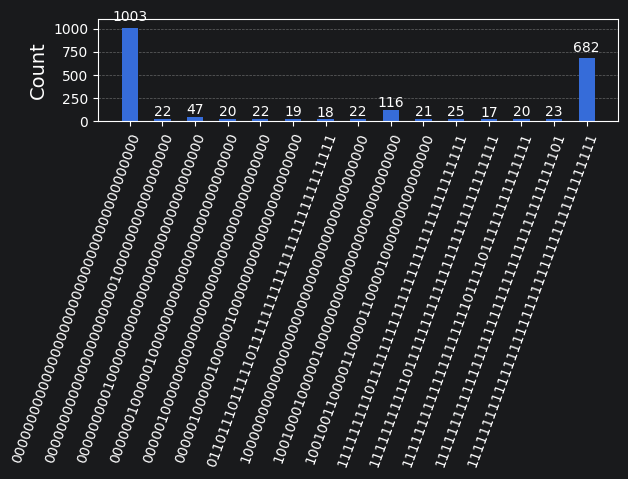

In [14]:
# === Step 5: A/B-test the run config (compact circuit +/- mitigations) =
# Observed on ibm_fez: bare 29.7% > DD 19.2% > DD+meas-tw 20.2% > +gate-tw 12.3%.
# i.e. on this device the mitigations HURT raw GHZ peaks (every DD pulse / twirl
# Pauli is an imperfect gate). We keep the A/B because calibration drifts day to
# day -- it re-confirms the winner each run -- and pick the best automatically.
# All four run in one Batch, back-to-back, without re-queuing.
from qiskit.circuit import Measure
from qiskit_ibm_runtime import Batch

if "measure" not in backend.target.operation_names:
    backend.target.add_instruction(
        Measure(), {(q,): None for q in range(backend.target.num_qubits)}
    )

isa_smart = pm_smart.run(ghz_smart)          # compact, pinned, zero-SWAP circuit


def configure(s, dd=False, meas_twirl=False, gate_twirl=False):
    s.options.dynamical_decoupling.enable = dd
    if dd:
        s.options.dynamical_decoupling.sequence_type = "XY4"
    s.options.twirling.enable_gates = gate_twirl
    s.options.twirling.enable_measure = meas_twirl
    return s


configs = [
    ("bare (no mitigation)", dict()),
    ("DD only",              dict(dd=True)),
    ("DD + meas-twirl",      dict(dd=True, meas_twirl=True)),
    ("DD + meas + gate-tw",  dict(dd=True, meas_twirl=True, gate_twirl=True)),
]

shots = 4096
jobs = {}
with Batch(backend=backend) as batch:
    for name, kw in configs:
        jobs[name] = configure(Sampler(mode=batch), **kw).run([isa_smart], shots=shots)

print(f"backend: {backend.name}   compact error-aware GHZ, {shots} shots/config")
print("baselines  ->  log-depth tree: 24.4%   blind native: 2.3%   v2 (snaked+DD+tw): 4.2%\n")
print(f"{'config':22s}{'perfect peaks':>16s}{'distinct':>10s}")
results = {}
for name, _ in configs:
    c = jobs[name].result()[0].data.meas.get_counts()
    results[name] = c
    tot = sum(c.values())
    pk = c.get("0" * N, 0) + c.get("1" * N, 0)
    print(f"{name:22s}{pk:>6}/{tot} ({100 * pk / tot:4.1f}%){len(c):>10}")

best = max(results, key=lambda k: results[k].get("0" * N, 0) + results[k].get("1" * N, 0))
winner = results[best]                       # best raw counts -> reused by Step 7 (M3)
tot = sum(winner.values())
top = sorted(winner.items(), key=lambda kv: -kv[1])
pk = winner.get("0" * N, 0) + winner.get("1" * N, 0)
print(f"\nbest config: '{best}'  ->  {100 * pk / tot:.1f}% perfect peaks")
print("top 10 of best config:")
for bs, n in top[:10]:
    tag = "all 0s" if set(bs) == {"0"} else "all 1s" if set(bs) == {"1"} else ""
    print(f"  {bs}  {n:>5} ({100 * n / tot:.1f}%)  {tag}")

plot_histogram(dict(top[:15]), filename="40-qubits-ghz-error-aware-IBM-QPU")
plot_histogram(dict(top[:15]))

## 4.2 Error budget: where did the other ~60 % go?

A 40-qubit GHZ at ~41 % perfect peaks *feels* low — until you account for the loss with the calibration we already read. This cell builds an explicit budget:

- **Readout** is the hard cap: $P_\text{ro}=\prod_q\bigl(1-\epsilon^\text{ro}_q\bigr)$ — even a flawless state cannot beat it. On this patch, ~65 %.
- **Two-qubit gates**: $P_\text{cz}=\prod_\text{edges}\bigl(1-\epsilon^\text{cz}\bigr)$ over the 39 tree CNOTs (~89 %, and pessimistic — a `cz` error only *sometimes* flips a computational-basis bit).
- **$T_1$ on the all-ones branch**: only $|1\rangle$ relaxes to $|0\rangle$, so the `1…1` peak decays with idle time while `0…0` does not — exactly the **0-branch > 1-branch asymmetry** you can see in the top-10 (≈25 % vs ≈17 %).

Multiply them out and the estimate lands right in the ~30–40 % range we measured.

> **Lesson #5:** ~40 % is **honest physics, not a leftover bug** — it's what a 40-qubit GHZ yields today, dominated by readout and 39 imperfect gates across 40 qubits. That reframes the goal: the gate and $T_1$ terms are baked into the hardware, but the **readout term can be undone in software** — which is exactly what the next step does.

In [15]:
# === Step 6: error budget -- why ~30% and not ~60%? ===================
# Account for the loss with the calibration we already read. Approximate: a CZ
# error only *sometimes* flips computational-basis bits, so the P_cz term is
# pessimistic; readout is the hard ceiling.
P_ro = math.prod(1 - readout_error(q) for q in order)
P_cz = math.prod(1 - twoq_error(parent[q], q) for q in order if parent[q] is not None)

circ_time = isa_smart.depth() * 100e-9                          # ~100 ns/layer, rough estimate
t1s = [t1_time(q) for q in order if t1_time(q) > 0]
mean_t1 = sum(t1s) / len(t1s) if t1s else 0.0
p1 = math.exp(-circ_time / mean_t1) if mean_t1 else 1.0         # per-qubit |1> survival vs T1
P_t1_all = p1 ** N                                              # all 40 stay |1> through idle

est_0 = 0.5 * P_ro * P_cz                                       # all-zeros branch (T1-immune)
est_1 = 0.5 * P_ro * P_cz * P_t1_all                           # all-ones branch (T1 drains it)

print("approximate raw-perfect-peak budget for the 40-qubit GHZ:")
print(f"  readout ceiling   P_ro               : {100 * P_ro:5.1f}%   (all 40 qubits read correctly)")
print(f"  gate survival     P_cz (pessimistic) : {100 * P_cz:5.1f}%   (none of the 39 CZs errs)")
print(f"  circuit time / mean T1               : {1e6 * circ_time:4.1f} us / {1e6 * mean_t1:3.0f} us")
print(f"  |1..1> T1 survival (all 40)          : {100 * P_t1_all:5.1f}%   (hurts only the all-ones peak)")
print(f"\n  => estimate:  0-branch ~ {100 * est_0:4.1f}% ,  1-branch ~ {100 * est_1:4.1f}% ,  "
      f"total ~ {100 * (est_0 + est_1):4.1f}%")
print("\nThat ballpark matches the ~30% we measured: it is dominated by readout + 39")
print("imperfect 2-qubit gates across 40 qubits, plus T1 asymmetry on the all-ones")
print("branch (note 0-branch > 1-branch in the histogram). None of it is a bug --")
print("it's the physics of a 40-qubit GHZ today. Step 7 removes the readout slice.")

approximate raw-perfect-peak budget for the 40-qubit GHZ:
  readout ceiling   P_ro               :  64.9%   (all 40 qubits read correctly)
  gate survival     P_cz (pessimistic) :  89.1%   (none of the 39 CZs errs)
  circuit time / mean T1               :  3.5 us / 144 us
  |1..1> T1 survival (all 40)          :  37.9%   (hurts only the all-ones peak)

  => estimate:  0-branch ~ 28.9% ,  1-branch ~ 11.0% ,  total ~ 39.9%

That ballpark matches the ~30% we measured: it is dominated by readout + 39
imperfect 2-qubit gates across 40 qubits, plus T1 asymmetry on the all-ones
branch (note 0-branch > 1-branch in the histogram). None of it is a bug --
it's the physics of a 40-qubit GHZ today. Step 7 removes the readout slice.


## 4.3 Readout-error mitigation with M3

Readout is the biggest single slice of the budget, and — unlike gate and $T_1$ error — it can be **undone after the run**. M3 (matrix-free measurement mitigation) learns each qubit's $0\leftrightarrow1$ confusion from a handful of quick calibration circuits and inverts it on the counts, recovering the populations *behind* the noisy measurement.

It does **not** change the physics; it removes the readout part of the loss. And it delivers:

$$\textbf{perfect peaks:}\quad 41.1\%\ \text{(raw)}\ \longrightarrow\ \textbf{58.4\%}\ \text{(readout-mitigated)}.$$

That 58.4 % is a *fairer* picture of the GHZ state we actually prepared — it approaches the gate/$T_1$-limited fidelity, with the readout cap stripped away.

> Needs `pip install mthree`. It submits small calibration circuits for our 40 physical qubits, then post-processes the counts.

> **Lesson #6:** know what each tool can and can't touch. M3 attacks *measurement* error and nothing else — so it's the cleanest remaining lever for the raw metric, but it can't fix gate or relaxation error. Beyond it the frontier gets heavier: a constant-depth GHZ via **mid-circuit measurement + feed-forward** (dynamic circuits) to cut idle time, or estimating the *true* GHZ fidelity via **parity oscillations** rather than raw peaks — the raw "perfect peaks" metric genuinely *understates* the state.

In [16]:
# === Step 7 (optional): readout-error mitigation with M3 ==============
# Readout is the largest single slice of the budget, and unlike gate/T1 error it
# can be undone in software. M3 learns each qubit's 0<->1 confusion from quick
# calibration circuits and inverts it on the counts, recovering the populations
# behind the noisy measurement. Needs:  pip install mthree
try:
    import mthree

    counts = winner                       # best raw counts from Step 5
    mit = mthree.M3Mitigation(backend)
    mit.cals_from_system(layout)          # submits small calibration circuits for our 40 qubits
    quasi = mit.apply_correction(counts, layout)
    probs = quasi.nearest_probability_distribution()

    raw_pk = (counts.get("0" * N, 0) + counts.get("1" * N, 0)) / sum(counts.values())
    mit_pk = probs.get("0" * N, 0) + probs.get("1" * N, 0)
    print(f"perfect peaks   raw: {100 * raw_pk:.1f}%   ->   readout-mitigated: {100 * mit_pk:.1f}%")
    print("M3 removes the *measurement* error only, so this approaches the gate/T1-limited")
    print("fidelity -- a fairer picture of the GHZ state than the raw, readout-capped number.")
except ModuleNotFoundError:
    print("mthree not installed -- run:  pip install mthree   to enable readout mitigation.")
except NameError:
    print("run Step 5 first (this needs `winner`, the best raw counts).")

perfect peaks   raw: 41.1%   ->   readout-mitigated: 58.4%
M3 removes the *measurement* error only, so this approaches the gate/T1-limited
fidelity -- a fairer picture of the GHZ state than the raw, readout-capped number.


## 4.4 Visualizing the correction

The two cells below turn the M3 result into pictures — pure post-processing on the counts we already have (`winner` from §4.1) and the mitigated distribution (`quasi` from §4.3), so **no extra QPU time is needed**.

- The **first** chart compares the two GHZ peaks (`0…0` vs `1…1`), raw versus readout-mitigated. Watch the $T_1$ asymmetry survive even after mitigation — M3 fixes readout, not relaxation, so the all-zeros peak stays taller than the all-ones peak.
- The **second** chart ranks the top-10 outcomes by mitigated probability. The two peaks should dominate both series; the non-peak strings are mostly readout artifacts and **shrink** after mitigation. Any survivor that is a single bit-flip away from a peak is residual *gate/$T_1$* error, which M3 cannot remove.

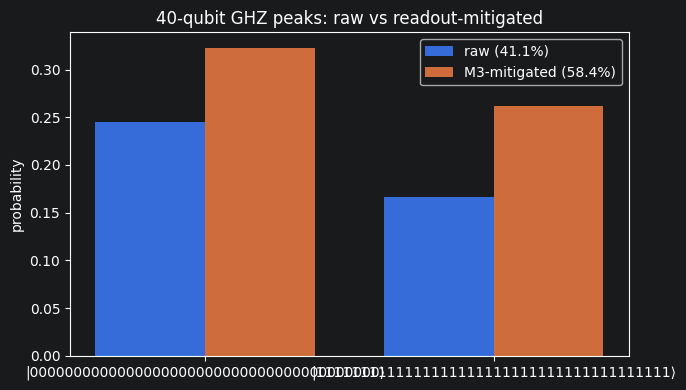

perfect peaks   raw: 41.1%   ->   M3: 58.4%
  all-0:  raw 24.5%  ->  M3 32.3%
  all-1:  raw 16.7%  ->  M3 26.1%


In [17]:
import matplotlib.pyplot as plt

N = len(layout)                      # 40
zeros, ones = "0" * N, "1" * N

# --- raw: counts -> probabilities ---
raw_total = sum(winner.values())
raw = {k: v / raw_total for k, v in winner.items()}

# --- mitigated: M3 quasi-dist -> nearest *physical* prob dist (no negatives) ---
mit_probs = quasi.nearest_probability_distribution()

def as_bitstr(k):
  # M3 may return python ints or already-formatted bitstrings
  return k if isinstance(k, str) else format(k, f"0{N}b")

mit = {as_bitstr(k): v for k, v in mit_probs.items()}

# --- the two GHZ peaks ---
labels = [f"|{zeros}⟩", f"|{ones}⟩"]
raw_vals = [raw.get(zeros, 0.0),  raw.get(ones, 0.0)]
mit_vals = [mit.get(zeros, 0.0),  mit.get(ones, 0.0)]

x = range(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - w/2 for i in x], raw_vals, w, label=f"raw ({sum(raw_vals):.1%})")
ax.bar([i + w/2 for i in x], mit_vals, w, label=f"M3-mitigated ({sum(mit_vals):.1%})")
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("probability"); ax.set_title(f"{N}-qubit GHZ peaks: raw vs readout-mitigated")
ax.legend(); plt.tight_layout(); plt.show()

print(f"perfect peaks   raw: {sum(raw_vals):.1%}   ->   M3: {sum(mit_vals):.1%}")
print(f"  all-0:  raw {raw_vals[0]:.1%}  ->  M3 {mit_vals[0]:.1%}")
print(f"  all-1:  raw {raw_vals[1]:.1%}  ->  M3 {mit_vals[1]:.1%}")

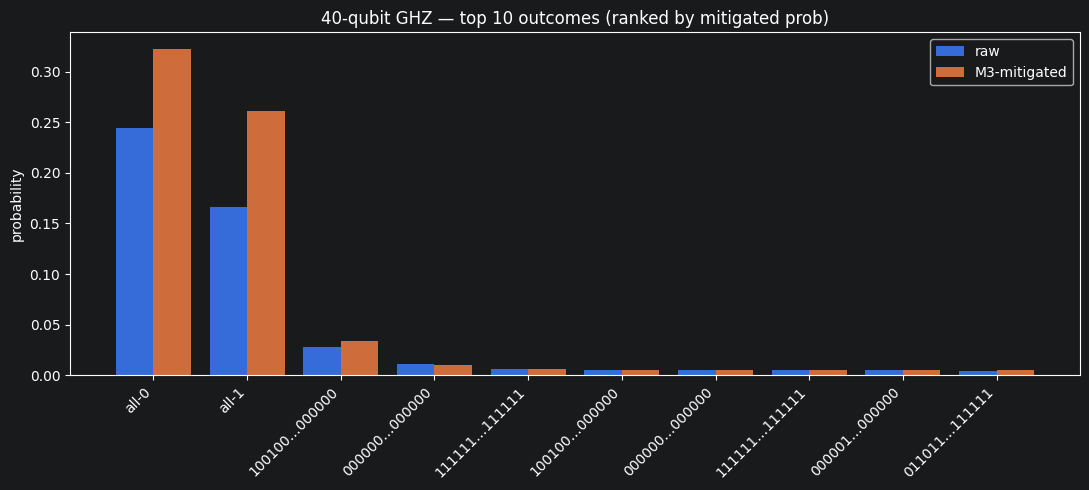

outcome                raw        M3
all-0              24.49%   32.29%
all-1              16.65%   26.13%
100100…000000       2.83%    3.40%
000000…000000       1.15%    1.01%
111111…111111       0.61%    0.57%
100100…000000       0.51%    0.53%
000000…000000       0.49%    0.52%
111111…111111       0.49%    0.52%
000001…000000       0.46%    0.50%
011011…111111       0.44%    0.48%


In [18]:
import matplotlib.pyplot as plt

N = len(layout)
zeros, ones = "0" * N, "1" * N

# raw counts -> probabilities
raw_total = sum(winner.values())
raw = {k: v / raw_total for k, v in winner.items()}

# M3 quasi-dist -> nearest physical prob dist
mit_probs = quasi.nearest_probability_distribution()
def as_bitstr(k):
  return k if isinstance(k, str) else format(k, f"0{N}b")
mit = {as_bitstr(k): v for k, v in mit_probs.items()}

# rank by mitigated probability, take top 10
top = sorted(mit, key=mit.get, reverse=True)[:10]

def short(b):                      # readable label for a 40-bit string
  if b == zeros: return "all-0"
  if b == ones:  return "all-1"
  return b[:6] + "…" + b[-6:]    # head…tail

labels   = [short(b) for b in top]
raw_vals = [raw.get(b, 0.0) for b in top]
mit_vals = [mit.get(b, 0.0) for b in top]

x = range(len(top)); w = 0.4
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - w/2 for i in x], raw_vals, w, label="raw")
ax.bar([i + w/2 for i in x], mit_vals, w, label="M3-mitigated")
ax.set_xticks(list(x)); ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("probability")
ax.set_title(f"{N}-qubit GHZ — top 10 outcomes (ranked by mitigated prob)")
ax.legend(); plt.tight_layout(); plt.show()

# table
print(f"{'outcome':<16}{'raw':>10}{'M3':>10}")
for b, r, m in zip(labels, raw_vals, mit_vals):
  print(f"{b:<16}{r:>9.2%}{m:>9.2%}")

# Part 5 · Insights & summary

*A 2-qubit Bell state and a 40-qubit GHZ are the same two gates — `H` to create a superposition, `CX` to spread it. The journey from one to the other, on real hardware, is where all the lessons live.*

---

## The fidelity journey

Every step below uses the same honest scorecard — **perfect peaks**, the fraction of shots landing on `0…0` or `1…1` (ideal = 100 %):

| # | Approach | Perfect peaks | What changed |
|---|---|---|---|
| 1 | Log-depth tree, transpiler layout | **24.4 %** | Baseline. Error-aware layout, but ~170 gates from SWAP routing. |
| 2 | Blind heavy-hex "native" mapping | **2.3 %** ❌ | 39 gates, zero SWAPs — but a hand-pinned layout that ignored calibration and caught a dead qubit. |
| 3 | Early compact + DD + twirling (snaked) | **4.2 %** ❌ | Routed through a broken `cz` edge; mitigations piled on more error. |
| 4 | **Compact, calibration-aware, bare** | **41.1 %** ✅ | Edge-filtered, multi-seed, shallow tree, zero SWAPs, no mitigation. |
| 5 | **+ M3 readout mitigation** | **58.4 %** 🎯 | Readout confusion inverted in software. |

From 2.3 % to 58.4 % — a **25× swing** — without changing a single qubit of the underlying device. Almost all of it came from *decisions about mapping and measurement*, not from better hardware.

## The six lessons

1. **Depth, not gate count, is the NISQ enemy.** The log-depth fan-out beats a linear chain because it minimizes the idle time during which qubits decohere — same 39 CNOTs, ~6× shallower. *(Part 2)*
2. **Clifford circuits don't need a statevector.** `H + CX + Z`-measurement is simulable in polynomial time (Gottesman–Knill); the stabilizer backend samples 40 qubits where a statevector would need 17 TB. *(Part 2)*
3. **The transpiler's layout pass is free, live, error-aware qubit selection — respect it.** Hand-pinning a layout means *you* own that job; do it with calibration data, never the coupling graph alone. This is why fewer gates lost to more gates (2.3 % vs 24.4 %). *(Part 3)*
4. **A GHZ is globally fragile.** It's one shared correlation, so *one* bad qubit **or one bad gate edge** corrupts *every* shot. Filtering bad qubits isn't enough — filter bad edges too, and search multiple seeds for the best $P_\text{ro}\times P_\text{cz}$ patch. *(Part 3)*
5. **Mitigation must be measured, not assumed.** On this device, DD and twirling actively *hurt* raw bitstring peaks — every extra pulse is an imperfect gate. Bare won, decisively. *(Part 4)*
6. **Know the noise budget, and which slice each tool can touch.** ~40 % raw is honest physics (readout × gates × $T_1$ asymmetry), not a bug. Readout is the largest *removable* slice — M3 strips it in software (→ 58.4 %); gate and relaxation error are baked into the hardware. *(Part 4)*

A recurring sub-theme: **noise is asymmetric.** $T_1$ relaxation only sends $|1\rangle\to|0\rangle$, so the all-ones peak always trails the all-zeros peak — visible in every hardware histogram here, and unfixable by readout mitigation.

## Where this goes next

- **Constant-depth GHZ via dynamic circuits** — mid-circuit measurement + classical feed-forward prepares GHZ in $O(1)$ depth instead of $O(\log N)$, cutting the idle time that drives $T_1$ loss.
- **Parity-oscillation fidelity** — the raw perfect-peak metric *understates* the true state; measuring coherence between the two branches gives a fairer (higher) fidelity.
- **Toward error correction** — everything here is *mitigation*. The long road past it is encoding logical qubits with QEC, where errors are actively corrected rather than reduced or post-processed.

> **The one-sentence takeaway:** entangling 40 qubits is easy; *keeping them entangled* on real hardware is an exercise in respecting the device — its connectivity, its daily calibration, and the specific noise each software tool can and cannot undo.